In [17]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## gambar asli

digunakan untuk menampilkan gambar aktivis.jpg dari folder Assets dalam mode grayscale tanpa menampilkan sumbu koordinat. Pertama, gambar dibaca menggunakan plt.imread() dan disimpan ke variabel gambar_asli. Kemudian gambar ditampilkan dengan plt.imshow() menggunakan cmap='gray' agar tampil dalam skala abu-abu. Terakhir, plt.axis('off') digunakan untuk menghilangkan sumbu x dan y agar tampilan gambar lebih bersih.

(np.float64(-0.5), np.float64(2721.5), np.float64(1293.5), np.float64(-0.5))

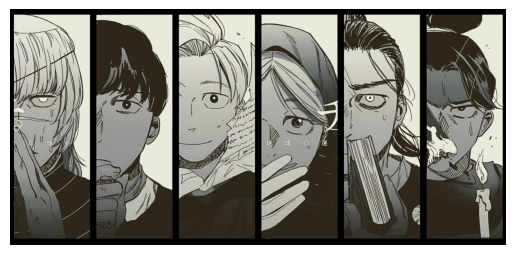

In [21]:
gambar_asli = plt.imread('Assets/aktivis.jpg')
plt.imshow(gambar_asli, cmap='gray')
plt.axis('off')

## potong gambar

berfungsi untuk memotong gambar secara vertikal menjadi beberapa bagian dengan lebar tertentu, lalu menampilkannya satu per satu lengkap dengan judul masing-masing. Fungsi potong_gambar() akan mengambil gambar yang diinput, menghitung berapa potongan yang diperlukan berdasarkan lebar yang ditentukan (lebar_potong), lalu memotong gambar dari kiri ke kanan dan menyimpannya ke dalam list. Selanjutnya, fungsi tampilkan_gambar() digunakan untuk menampilkan semua potongan gambar secara berjajar (horizontal), dengan judul yang sesuai di atas masing-masing gambar. Agar warna tampil dengan benar di matplotlib, urutan warnanya dibalik dari BGR ke RGB ([:, :, ::-1]). Setelah itu, gambar asli 'aktivis.jpg' dibaca dengan cv2.imread(), dipotong dengan lebar 455 piksel per potong, dan hasilnya ditampilkan bersama daftar judul: "badeni", "albert", "Rafal", "jolenta", "oczy", dan "draka".

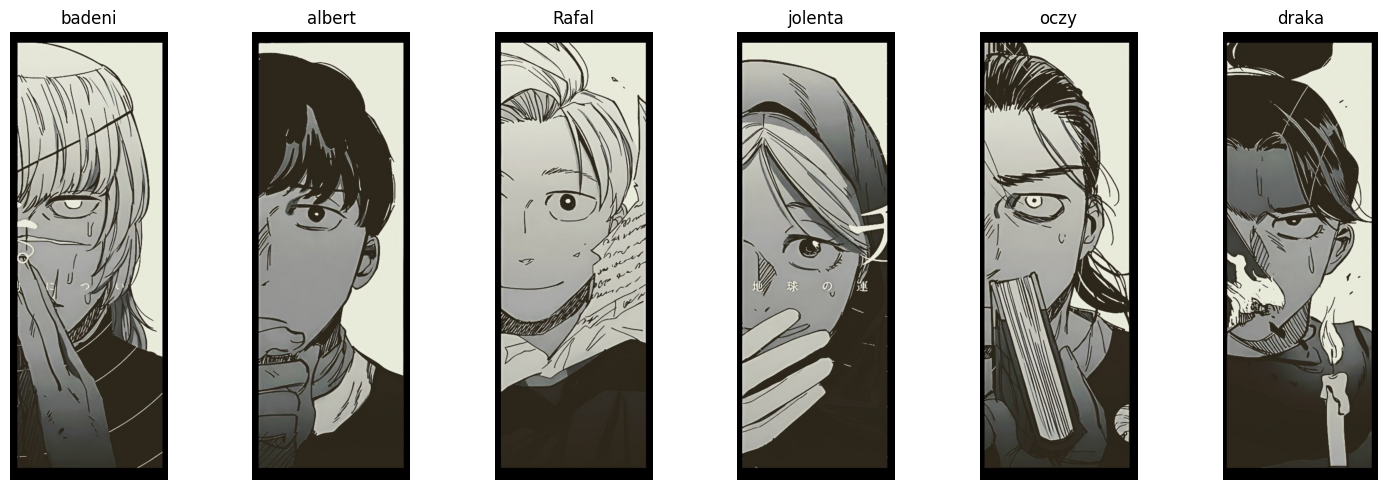

In [ ]:
def potong_gambar(gambar, lebar_potong):
    tinggi, lebar = gambar.shape[:2]
    hasil_potong = []
    jumlah_potongan = lebar // lebar_potong + (1 if lebar % lebar_potong else 0)

    for i in range(jumlah_potongan):
        awal = i * lebar_potong
        akhir = min(awal + lebar_potong, lebar)
        hasil_potong.append(gambar[:, awal:akhir])
    
    return hasil_potong

def tampilkan_gambar(daftar_gambar, daftar_judul):
    plt.figure(figsize=(15, 5))
    for idx in range(len(daftar_gambar)):
        plt.subplot(1, len(daftar_gambar), idx + 1)
        plt.imshow(daftar_gambar[idx][:, :, ::-1]) 
        plt.title(daftar_judul[idx])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

gambar = cv2.imread('Assets/aktivis.jpg')
lebar_per_potong = 455
gambar_terpotong = potong_gambar(gambar, lebar_per_potong)
judul = ["badeni", "albert", "Rafal", "jolenta", "oczy", "draka"]

tampilkan_gambar(gambar_terpotong, judul)

## ekualisasi

terdiri dari dua fungsi yaitu normalisasi_dan_grayscale() dan histogram_ekualisasi(), yang digunakan untuk mempersiapkan gambar grayscale dan memperbaiki kontrasnya menggunakan ekualisasi histogram. Pertama, normalisasi_dan_grayscale() memastikan gambar berada dalam format uint8, jika gambar masih dalam rentang [0,1], maka dikalikan 255 terlebih dahulu. Lalu jika gambar masih berwarna (RGB), fungsi ini akan mengubahnya menjadi grayscale. Setelah gambar menjadi grayscale, histogram_ekualisasi() menghitung histogram piksel, membuat fungsi distribusi kumulatif (CDF), dan membentuk peta transformasi untuk menyebar nilai-nilai piksel agar kontras gambar lebih merata. Gambar hasil ekualisasi kemudian ditampilkan menggunakan matplotlib. 

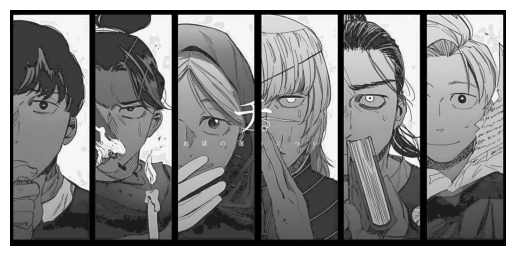

In [ ]:
def normalisasi_dan_grayscale(img):
    
    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)
    
    if img.ndim == 3 and img.shape[2] == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    return img

def histogram_ekualisasi(input_gambar):
    tinggi, lebar = input_gambar.shape
    histogram = np.bincount(input_gambar.flatten(), minlength=256)

    cdf = histogram.cumsum()
    transform_map = np.floor((cdf / cdf[-1]) * 255).astype(np.uint8)

    output = transform_map[input_gambar]
    return output

grayscale_img = normalisasi_dan_grayscale(gambar_baru)

ekual1 = histogram_ekualisasi(grayscale_img)
ekual2 = histogram_ekualisasi(grayscale_img)

plt.imshow(ekual1, cmap='gray')
plt.axis('off')
plt.show()

## compare histogram sebelum dan setelah ekualisasi

digunakan untuk menampilkan perbandingan histogram antara gambar sebelum dan sesudah proses ekualisasi, agar bisa terlihat seberapa besar distribusi pikselnya berubah. Fungsi konversi_ke_uint8() memastikan semua gambar berada dalam format 8-bit (0–255), karena proses histogram hanya valid jika datanya dalam format ini. Kalau gambar masih dalam format float (misalnya hasil normalisasi), fungsi ini akan mengalikan nilainya dengan 255 (kalau masih dalam skala 0–1), lalu mengubahnya jadi uint8. Fungsi hitung_histogram() menghitung jumlah kemunculan tiap nilai piksel (0–255) dalam gambar dengan menggunakan np.unique. Setelah histogram untuk gambar asli (hist_awal) dan hasil ekualisasi (hist_ekual) dihitung, keduanya kemudian digambarkan dalam dua subplot yaitu kiri untuk sebelum ekualisasi, kanan untuk sesudahnya. 

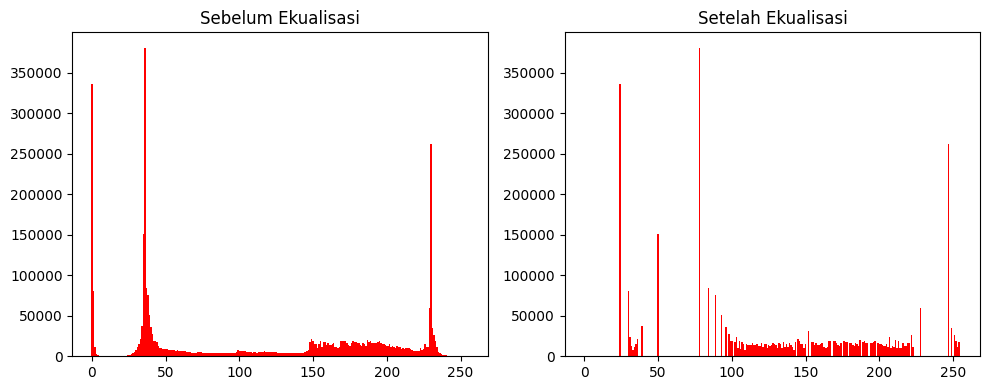

In [ ]:

def konversi_ke_uint8(img):
    if img.dtype in [np.float32, np.float64]:
        return np.clip(np.round(img * 255 if img.max() <= 1.0 else img), 0, 255).astype(np.uint8)
    return img

def hitung_histogram(img):
    hist = np.zeros(256, dtype=int)
    nilai, frekuensi = np.unique(img, return_counts=True)
    for v, f in zip(nilai, frekuensi):
        if v < 256:
            hist[v] = f
    return hist

awal_uint8 = konversi_ke_uint8(gambar_baru)
ekual_uint8 = konversi_ke_uint8(hasil)

hist_awal = hitung_histogram(awal_uint8)
hist_ekual = hitung_histogram(ekual_uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('Sebelum Ekualisasi')
plt.bar(np.arange(256), hist_awal, width=1.0, color='red')

plt.subplot(1, 2, 2)
plt.title('Setelah Ekualisasi')
plt.bar(np.arange(256), hist_ekual, width=1.0, color='red')

plt.tight_layout()
plt.show()

## spesifikasi

melakukan pencocokan histogram (histogram matching) antara gambar gambar_baru dan dua referensi berbeda (propaganda_ref dan draka_ref), lalu menampilkan hasilnya berdampingan dengan hasil susunan gambar-gambar kecil yang telah diproses. Fungsi pencocokan_histogram() bekerja dengan menghitung histogram dan CDF dari gambar sumber dan referensi, lalu mencocokkan nilai intensitas piksel dari sumber ke nilai yang paling mendekati pada CDF referensi. Setelah dua gambar utama diproses (hasil_propaganda dan hasil_draka), bagian-bagian kecil dari gambar (gambar1 sampai gambar6) diproses satu per satu yaitu pertama diekualisasi (agar kontrasnya merata), lalu dicocokkan ke draka_ref agar gaya warnanya seragam. Semua bagian kemudian disusun ulang mengikuti urutan yang ditentukan di urutan_susun, dan digabungkan secara horizontal menjadi satu gambar panjang (gabungan_akhir) yang ditampilkan di sebelah kanan hasil hasil_propaganda. Hasil akhir ini memperlihatkan transformasi gaya visual dan urutan susunan gambar dengan efek histogram yang sudah disesuaikan. 

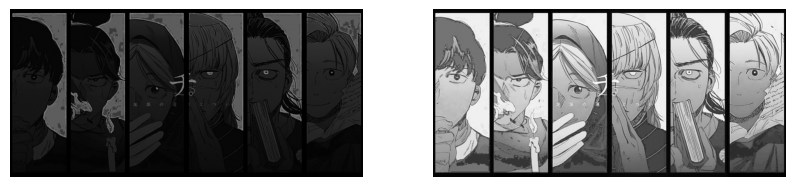

In [ ]:
draka_ref = cv.imread('Assets/draka.jpg', cv.IMREAD_GRAYSCALE)
propaganda_ref = cv.imread('Assets/propaganda.jpg', cv.IMREAD_GRAYSCALE)

def pencocokan_histogram(sumber, referensi):
    tinggi, lebar = sumber.shape
    data_sumber = sumber.ravel()
    data_referensi = referensi.ravel()

    hist_sumber, _ = np.histogram(data_sumber, bins=256, range=(0, 256))
    hist_referensi, _ = np.histogram(data_referensi, bins=256, range=(0, 256))

    cdf_sumber = np.cumsum(hist_sumber).astype(np.float64)
    cdf_sumber /= cdf_sumber[-1]
    cdf_referensi = np.cumsum(hist_referensi).astype(np.float64)
    cdf_referensi /= cdf_referensi[-1]

    hasil_mapping = np.searchsorted(cdf_referensi, cdf_sumber)
    hasil_mapping = np.clip(hasil_mapping, 0, 255)

    hasil_akhir = hasil_mapping[data_sumber].reshape((tinggi, lebar)).astype(np.uint8)
    return hasil_akhir

plt.figure(figsize=(10, 10))
hasil_propaganda = pencocokan_histogram(gambar_baru, propaganda_ref)
hasil_draka = pencocokan_histogram(gambar_baru, draka_ref)

plt.subplot(1, 2, 1)
plt.imshow(hasil_propaganda, cmap='gray')
plt.axis('off')

gambar_bagian = [gambar1, gambar2, gambar3, gambar4, gambar5, gambar6]
urutan_susun = [1, 5, 3, 0, 4, 2]  

bagian_hasil = []
for bagian in gambar_bagian:
    hasil_eq = ekualisasi(bagian)
    hasil_spesifikasi = pencocokan_histogram(hasil_eq, draka_ref)
    bagian_hasil.append(hasil_spesifikasi)

gabungan_akhir = np.zeros((tinggi, total_lebar), dtype=np.uint8)
posisi_x = 0
for idx in urutan_susun:
    lebar_bagian = bagian_hasil[idx].shape[1]
    gabungan_akhir[:, posisi_x:posisi_x + lebar_bagian] = bagian_hasil[idx]
    posisi_x += lebar_bagian

plt.subplot(1, 2, 2)
plt.imshow(gabungan_akhir, cmap='gray')
plt.axis('off')
plt.show()

## gabung dan spesifikasi potongan gambar

gapahaamm